-- https://aiolux.com/contrasts/side-by-side?relative_performance=true&scroll=quick_comparison&symbol_arr=PYPL%2CSPY&time_span=2y

[*********************100%%**********************]  1 of 1 completed
/home/jovyan/.conda-envs/datalakeutils/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':


The most recent market reversal date is: 2023-02-02 00:00:00


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Date
2023-02-02    1.000000
2023-02-03    0.998668
2023-02-06    0.995148
2023-02-07    0.989635
2023-02-08    0.984467
                ...   
2024-06-12    0.814073
2024-06-13    0.811606
2024-06-14    0.809573
2024-06-17    0.809008
2024-06-18    0.808658
Name: Adaptive Relative Strength, Length: 346, dtype: float64


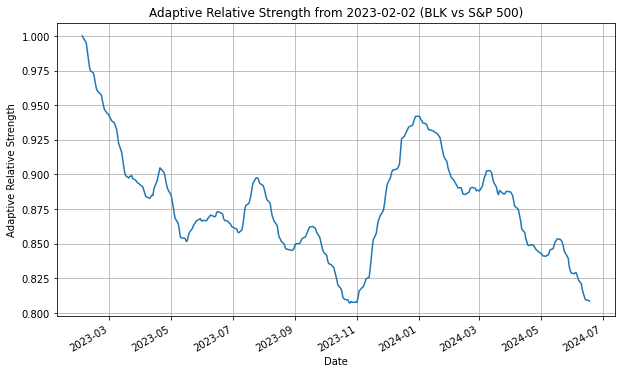

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Function to identify the most recent market reversal date using SMA crossovers
def identify_recent_reversal_date(data, short_window=50, long_window=200):
    data['SMA_Short'] = data['Adj Close'].rolling(window=short_window).mean()
    data['SMA_Long'] = data['Adj Close'].rolling(window=long_window).mean()
    data['Signal'] = 0
    data['Signal'][short_window:] = np.where(data['SMA_Short'][short_window:] > data['SMA_Long'][short_window:], 1, 0)
    data['Position'] = data['Signal'].diff()

    reversal_dates = data[data['Position'].abs() == 1].index
    if len(reversal_dates) > 0:
        return reversal_dates[-1]
    else:
        return None

# Function to calculate adaptive relative strength from a specific start date
def calculate_ars_from_date(stock_ticker, index_ticker, start_date, end_date, ema_span=10):
    # Download historical data
    stock_data = yf.download(stock_ticker, start=start_date, end=end_date)
    index_data = yf.download(index_ticker, start=start_date, end=end_date)

    # Calculate daily returns
    stock_data['Return'] = stock_data['Adj Close'].pct_change()
    index_data['Return'] = index_data['Adj Close'].pct_change()

    # Calculate cumulative returns from the start date
    stock_data['Cumulative Return'] = (stock_data['Adj Close'] / stock_data['Adj Close'].iloc[0])
    index_data['Cumulative Return'] = (index_data['Adj Close'] / index_data['Adj Close'].iloc[0])

    # Calculate Relative Strength
    stock_data['Relative Strength'] = stock_data['Cumulative Return'] / index_data['Cumulative Return']

    # Calculate Adaptive Relative Strength using Exponential Moving Average (EMA)
    stock_data['Adaptive Relative Strength'] = stock_data['Relative Strength'].ewm(span=ema_span, adjust=False).mean()

    return stock_data['Adaptive Relative Strength']

# Parameters
stock_ticker = 'BLK'   # Broadcom Inc.
index_ticker = '^GSPC' # S&P 500
long_window = 200      # Long window for SMA
short_window = 50      # Short window for SMA
ema_span = 10          # EMA span for smoothing

# Download historical data for reversal date identification
index_data = yf.download(index_ticker, start='2000-01-01', end=datetime.today().strftime('%Y-%m-%d'))

# Identify the most recent market reversal date
reversal_date = identify_recent_reversal_date(index_data, short_window, long_window)

if reversal_date:
    print(f"The most recent market reversal date is: {reversal_date}")

    # Calculate ARS from the reversal date to today
    adaptive_relative_strength = calculate_ars_from_date(stock_ticker, index_ticker, reversal_date.strftime('%Y-%m-%d'), datetime.today().strftime('%Y-%m-%d'), ema_span)

    # Display the results
    print(adaptive_relative_strength)

    # Optional: Plotting the Adaptive Relative Strength
    plt.figure(figsize=(10, 6))
    adaptive_relative_strength.plot(title=f'Adaptive Relative Strength from {reversal_date.strftime("%Y-%m-%d")} ({stock_ticker} vs S&P 500)')
    plt.xlabel('Date')
    plt.ylabel('Adaptive Relative Strength')
    plt.grid(True)
    plt.show()
else:
    print("No reversal date identified in the provided data range.")
